### All the required imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, PolynomialFeatures
from sklearn.linear_model    import LinearRegression, Ridge, LogisticRegression
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_squared_error, r2_score, accuracy_score

### Loading the data

In [2]:
df = pd.read_csv("F://Ml-Projects//Data//Titanic//cleaned_train_data.csv")
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,has_cabin,embarked_Q,embarked_S
0,0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,1,0,38.0,1,0,71.2833,1,0,0
2,2,1,3,0,26.0,0,0,7.9250,0,0,1
3,3,1,1,0,35.0,1,0,53.1000,1,0,1
4,4,0,3,1,35.0,0,0,8.0500,0,0,1


### plotting all the features against the required one

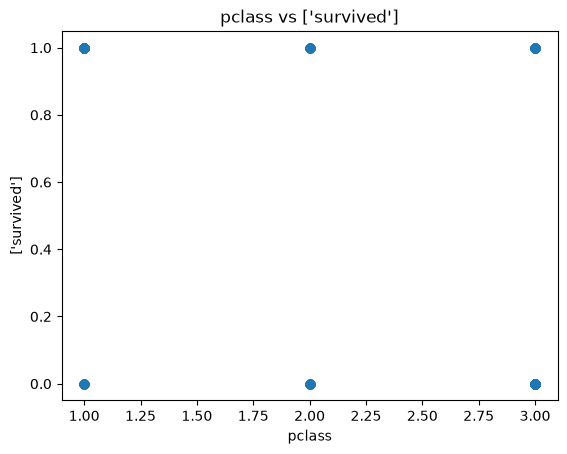

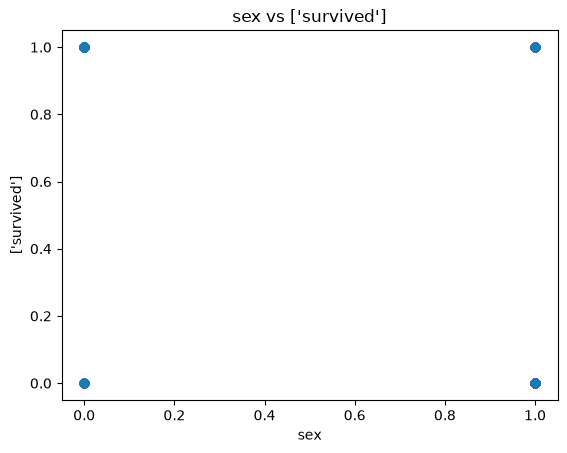

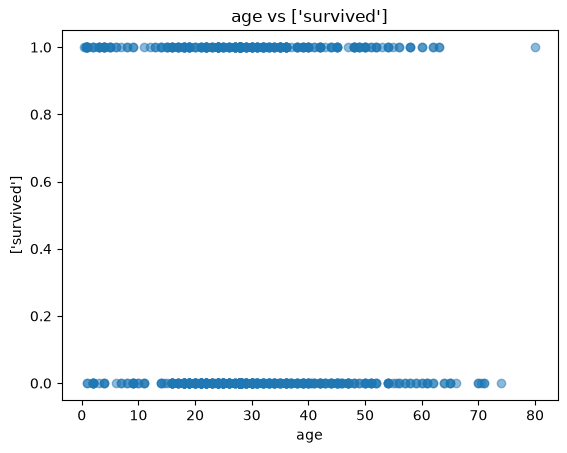

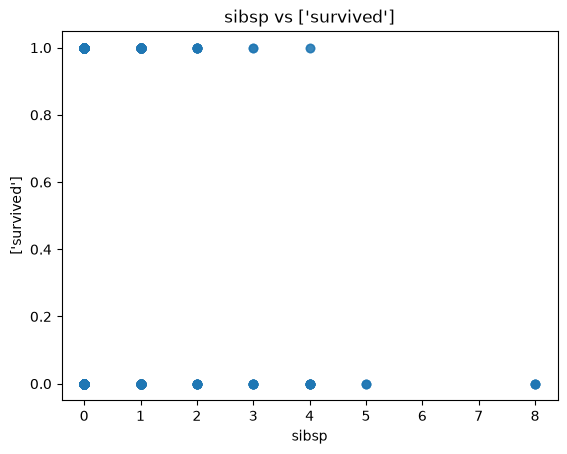

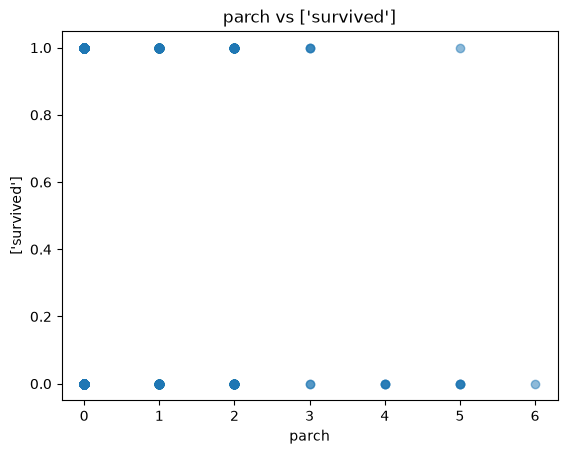

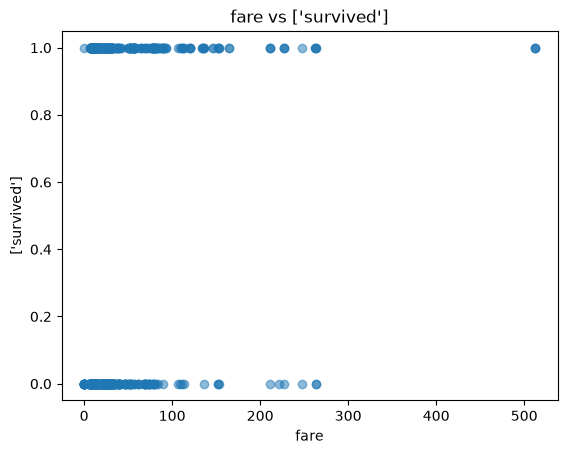

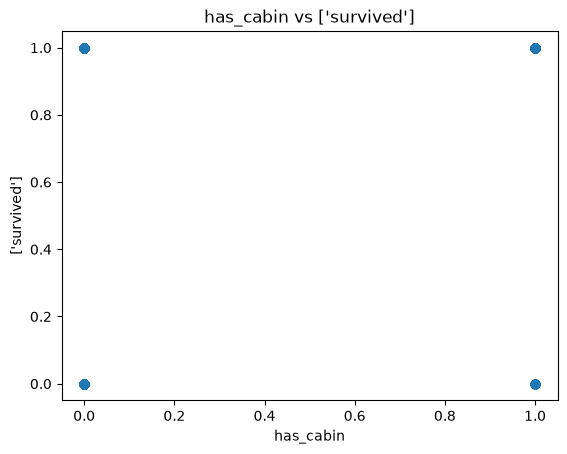

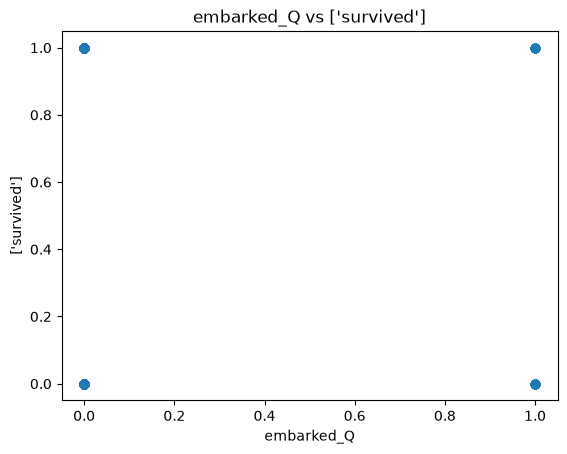

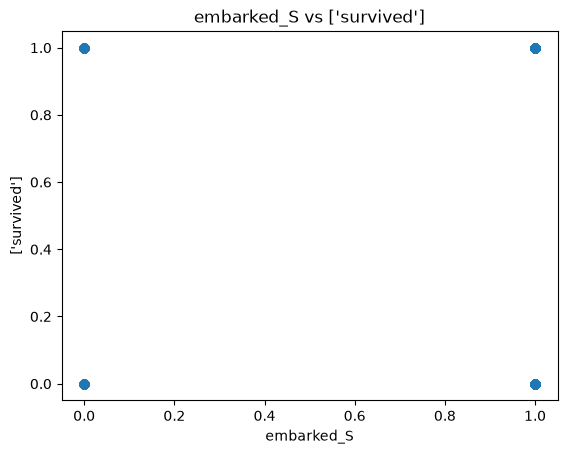

In [4]:
feature_coloumn = ["pclass" , "sex" , "age" , "sibsp" , "parch" , "fare" , "has_cabin" , "embarked_Q" , "embarked_S"]
required_coloumn = ["survived"]

for col in feature_coloumn:
    plt.scatter(df[col] , df[required_coloumn] , alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(required_coloumn)
    plt.title(f"{col} vs {required_coloumn}")
    plt.show()

### Splitting the data

In [5]:
x = df[feature_coloumn].values
y = df[required_coloumn].values

x_train , x_temp , y_train , y_temp = train_test_split(x , y , test_size=0.30 , random_state=42)
x_val , x_test , y_val , y_test = train_test_split(x_temp , y_temp , test_size=0.50 , random_state=42)

### Creating the pipeline

In [8]:
pipe_clf = Pipeline([
    ('scale' , StandardScaler()),
    ('model' , LogisticRegression(C=1.0 , max_iter=1000)),
])

pipe_clf.fit(x_train , y_train)

y_pred_clf = pipe_clf.predict(x_val)  # predicting the value 0 and 1
y_prob_clf = pipe_clf.predict_proba(x_val)[:,1]  # it returns 2d array with probability of both 0 and 1 we are only getting the probability of 1

print(f"accuracy_score : {accuracy_score(y_val , y_pred_clf):.4f}")


accuracy_score : 0.8284


f:\Ml-Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Plotting predicted probabilities

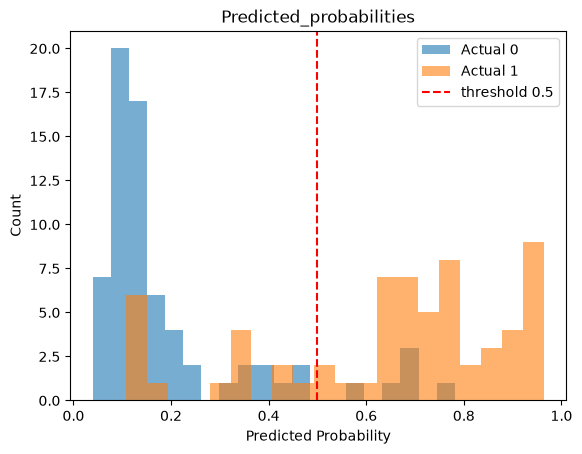

In [16]:
y_val = y_val.ravel()
plt.hist(y_prob_clf[y_val == 0] , bins=20 , alpha=0.6 , label="Actual 0")
plt.hist(y_prob_clf[y_val == 1] , bins = 20 , alpha = 0.6 , label="Actual 1")
plt.axvline(0.5 , color='red', linestyle='--', label='threshold 0.5')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted_probabilities")
plt.legend()
plt.show()

### Checking overfitting and underfitting

In [18]:
train_acc = accuracy_score(y_train ,pipe_clf.predict(x_train))
val_acc = accuracy_score(y_val , y_pred_clf)

print(f"Training accuray : {train_acc}")
print(f"val acc : {val_acc}")

if train_acc < 0.75 and val_acc < 0.75:
    print('→ HIGH BIAS (underfitting) — add more features or increase C')
elif train_acc - val_acc > 0.1:
    print('→ HIGH VARIANCE (overfitting) — decrease C')
else:
    print('→ Good fit')

Training accuray : 0.7945425361155698
val acc : 0.8283582089552238
→ Good fit


### Checking if we can improve the accuracy by changing c

In [20]:
for c in [0.01 , 0.1 , 1 , 10.0 , 100.0]:
    pipe = Pipeline([
        ('scale' , StandardScaler()),
        ('model' , LogisticRegression(C=c , max_iter=1000))
    ])
    pipe.fit(x_train , y_train)
    value_accuracy = accuracy_score(y_val , pipe.predict(x_val))
    print(f"for the value of c : {c} is accuracy is {value_accuracy:.4f}")

for the value of c : 0.01 is accuracy is 0.8209
for the value of c : 0.1 is accuracy is 0.8284
for the value of c : 1 is accuracy is 0.8284
for the value of c : 10.0 is accuracy is 0.8284
for the value of c : 100.0 is accuracy is 0.8284


f:\Ml-Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
f:\Ml-Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
f:\Ml-Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
f:\Ml-Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example 

### Final test

In [21]:
test_acc = accuracy_score(y_test , pipe_clf.predict(x_test))
print(f"Test accuracy : {test_acc:.4f}")

Test accuracy : 0.8060


### Actual data fitting

In [24]:
testing_df = pd.read_csv("F://Ml-Projects//Data//Titanic//cleaned_train_data.csv")
raw_testing_df = pd.read_csv("F://Ml-Projects//Data//Titanic//train.csv")
passenger_ids = raw_testing_df["PassengerId"]
all_columns = testing_df[["pclass","sex","age","sibsp","parch","fare","has_cabin","embarked_Q","embarked_S"]]

final_predict = pipe_clf.predict(all_columns)

submission = pd.DataFrame({
    "PassengerId" : passenger_ids,
    "Survived" : final_predict
})

submission.to_csv("F://Ml-Projects//Titanic//Ml_training//final_prediction.csv" , index=False)

f:\Ml-Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
